In [11]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

print("Path to dataset files:", path)

c:\Users\hashe\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\hashe\.cache\kagglehub\datasets\mlg-ulb\creditcardfraud\versions\3


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import GridSearchCV

In [13]:
data = pd.read_csv(path + "/creditcard.csv")

In [14]:
data = data.drop(['Time'], axis=1)

Text(0.5, 1.0, 'Count of each Target Class')

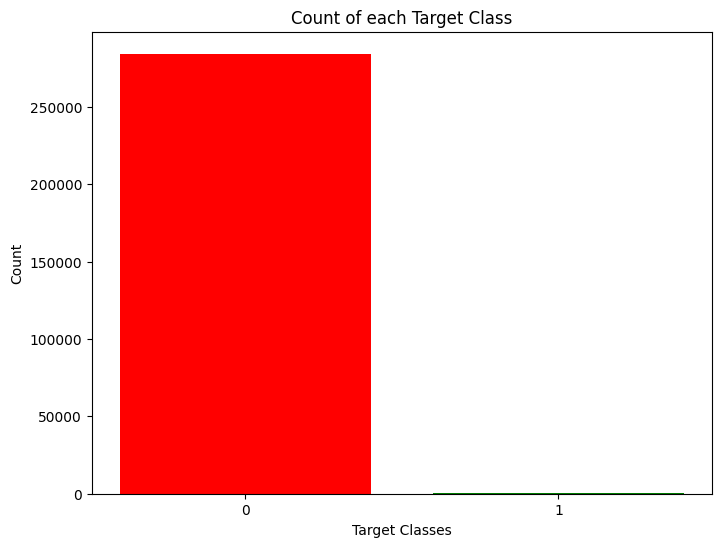

In [15]:
rcParams['figure.figsize'] = 8,6
plt.bar(data['Class'].unique(), data['Class'].value_counts(), color = ['red', 'green'])
plt.xticks([0, 1])
plt.xlabel('Target Classes')
plt.ylabel('Count')
plt.title('Count of each Target Class')

In [16]:
x = data.drop( ['Class'], axis=1)
y = data['Class' ]

In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [12]:
hyper_param = {'criterion': ['entropy' ], 'max_depth' : [4]}
tree_Gridsearch_param = GridSearchCV(estimator=DecisionTreeClassifier(), param_grid=hyper_param, cv=5)
tree_Gridsearch_param.fit(x_train, y_train)
tree_Gridsearch_param.best_params_

{'criterion': 'entropy', 'max_depth': 4}

In [14]:
hyper_param_bag = {'n_estimators':[3,4,6,10]}
tree_Gridsearch_param_bag = GridSearchCV(estimator=BaggingClassifier(), param_grid=hyper_param_bag,scoring = 'roc_auc', cv=5)
tree_Gridsearch_param_bag.fit(x_train, y_train)
tree_Gridsearch_param_bag.best_params_

{'n_estimators': 6}

In [20]:
hyper_param_RF = {'criterion':['entropy'],'max_depth':[2,3,10], 'n_estimators':[40,60,100], 'max_features':['sqrt']}
Tree_Gridsearch_paramters_Rf=GridSearchCV(RandomForestClassifier(),hyper_param_RF,scoring='roc_auc',n_jobs=-1,cv=5,verbose=2)
Tree_Gridsearch_paramters_Rf.fit(x_train, y_train)
Tree_Gridsearch_paramters_Rf.best_params_
 

Fitting 5 folds for each of 9 candidates, totalling 45 fits


{'criterion': 'entropy',
 'max_depth': 10,
 'max_features': 'sqrt',
 'n_estimators': 60}

In [24]:
#Prediction Using the Model
Final_Model = Tree_Gridsearch_paramters_Rf.best_estimator_
y_pred = Final_Model.predict(x_test)
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
cm1 = confusion_matrix(y_test, y_pred)
print(cm1)
print(classification_report(y_test, y_pred, target_names=["Safe", "Fraud"]))
 
#Calculate sensitivity and specificity
 
total1=sum(sum(cm1))
accuracy1=(cm1[0,0]+cm1[1,1])/total1
print ('Accuracy : ', accuracy1)
 
sensitivity1 = cm1[0,0]/(cm1[0,0]+cm1[0,1])
print('Sensitivity : ', sensitivity1 )
 
specificity1 = cm1[1,1]/(cm1[1,0]+cm1[1,1])
print('Specificity : ', specificity1)

[[56862     2]
 [   21    77]]
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     56864
       Fraud       0.97      0.79      0.87        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962

Accuracy :  0.9995962220427653
Sensitivity :  0.9999648283624085
Specificity :  0.7857142857142857


In [25]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter
from sklearn.ensemble import RandomForestClassifier

ros = RandomOverSampler(random_state=42)
x_ros, y_ros = ros.fit_resample(x_train, y_train)
print('Original dataset shape %s' % Counter(y_train))
print('Resampled dataset shape %s' % Counter(y_ros))


Original dataset shape Counter({0: 227451, 1: 394})
Resampled dataset shape Counter({0: 227451, 1: 227451})


In [26]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(random_state=42)
x_ros, y_ros = rus. fit_resample(x_train, y_train)
print('Original dataset shape', Counter(y))
print('Resample dataset shape', Counter(y_ros))

Original dataset shape Counter({0: 284315, 1: 492})
Resample dataset shape Counter({0: 394, 1: 394})
